# Stage 4:- Clinical Validation and Survival Analysis

In [1]:
import os
import sys
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mygene
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

In [ ]:
# Load the replicated genes file

DIR_TABLES = r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables"
DIR_FIGURES = r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots"

os.makedirs(DIR_TABLES, exist_ok=True)
os.makedirs(DIR_FIGURES, exist_ok=True)

# Locate the replicated genes file
replicated_filename = "replicated_genes.csv"
input_path = os.path.join(DIR_TABLES, replicated_filename)

if not os.path.exists(input_path):
    # Check for alternative naming if necessary
    alt_path = os.path.join(DIR_TABLES, "15_replicated_genes.csv")
    if os.path.exists(alt_path):
        input_path = alt_path
    else:
        raise FileNotFoundError(f"Could not find replicated genes CSV in: {DIR_TABLES}")

rep_df = pd.read_csv(input_path)
replicated_genes = rep_df["gene"].dropna().astype(str).str.strip().unique().tolist()
print(f"Loaded {len(replicated_genes)} candidate genes to test for TCGA survival.")

Loaded 61 candidate genes to test for TCGA survival.


In [ ]:

# 2. Fetching the TCGA-OV Clinical Data from cBioPortal

BASE = "https://www.cbioportal.org/api"
STUDY = "ov_tcga_pan_can_atlas_2018"
PROFILE_ID = f"{STUDY}_rna_seq_v2_mrna"
SAMPLE_LIST_ID = f"{STUDY}_all"

print("Fetching TCGA-OV clinical survival parameters...")
clin_patient = pd.read_json(
    f"{BASE}/studies/{STUDY}/clinical-data?clinicalDataType=PATIENT"
).pivot_table(index="patientId", columns="clinicalAttributeId", values="value", aggfunc="first")

try:
    clin_sample = pd.read_json(
        f"{BASE}/studies/{STUDY}/clinical-data?clinicalDataType=SAMPLE"
    ).pivot_table(index="patientId", columns="clinicalAttributeId", values="value", aggfunc="first")
    clin = clin_patient.combine_first(clin_sample)
except Exception:
    clin = clin_patient

os_month_col = next((c for c in clin.columns if c.upper() in ["OS_MONTHS", "OS_TIME", "OVERALL_SURVIVAL_MONTHS"]), None)
os_status_col = next((c for c in clin.columns if c.upper() in ["OS_STATUS", "VITAL_STATUS"]), None)

clin["patient_id_clean"] = clin.index.astype(str).str.slice(0, 12).str.upper()
print(f"Identified endpoints: Months='{os_month_col}', Status='{os_status_col}' across {len(clin)} patients.")

mg = mygene.MyGeneInfo()

Fetching TCGA-OV clinical survival parameters...
Identified endpoints: Months='OS_MONTHS', Status='OS_STATUS' across 585 patients.


In [ ]:

# 3. Retrieve RNA-Seq Expression per Gene

def get_tcga_expression(gene_symbol):
    try:
        query = mg.query(gene_symbol, scopes="symbol", fields="entrezgene", species="human")
        hits = query.get("hits", [])
        if not hits or "entrezgene" not in hits[0]:
            return None
        entrez = int(hits[0]["entrezgene"])

        url = f"{BASE}/molecular-profiles/{PROFILE_ID}/molecular-data/fetch"
        payload = {"entrezGeneIds": [entrez], "sampleListId": SAMPLE_LIST_ID}
        
        response = requests.post(url, json=payload, headers={"Content-Type": "application/json"}, timeout=30)
        if response.status_code != 200:
            return None
            
        data = response.json()
        if not isinstance(data, list) or len(data) == 0:
            return None

        df_exp = pd.DataFrame(data)
        
        # Map sample ID barcodes (TCGA-04-1331-01 -> TCGA-04-1331)
        if "patientId" in df_exp.columns:
            df_exp["patient_id_clean"] = df_exp["patientId"].astype(str).str.slice(0, 12).str.upper()
        elif "sampleId" in df_exp.columns:
            df_exp["patient_id_clean"] = df_exp["sampleId"].astype(str).str.slice(0, 12).str.upper()
        else:
            return None

        # Return mean expression per patient
        return df_exp.groupby("patient_id_clean")["value"].mean().reset_index()

    except Exception:
        return None

In [ ]:

# 4. Survival Modeling & Kaplan-Meier Curve Plotting

def run_survival(gene_symbol, make_plot=True):
    tcga_gene = get_tcga_expression(gene_symbol)
    if tcga_gene is None or tcga_gene.empty:
        print(f"[{gene_symbol}] Skipped: No TCGA expression data found.")
        return None

    merged = clin.merge(tcga_gene, on="patient_id_clean", how="inner")
    
    merged["OS_MONTHS"] = pd.to_numeric(merged[os_month_col], errors="coerce")
    merged["value"] = pd.to_numeric(merged["value"], errors="coerce")
    merged = merged.dropna(subset=["OS_MONTHS", "value"])
    merged = merged[merged["OS_MONTHS"] > 0]

    # Event indicator: 1 = Deceased, 0 = Living
    merged["event"] = merged[os_status_col].astype(str).str.contains("1|DECEASED|DEAD", case=False).astype(int)

    if len(merged) < 15 or merged["value"].nunique() <= 1:
        return None

    # Median stratification into High vs Low expression
    med_val = merged["value"].median()
    merged["group"] = np.where(merged["value"] > med_val, "High expression", "Low expression")
    
    high_mask = merged["group"] == "High expression"
    low_mask = merged["group"] == "Low expression"

    if high_mask.sum() < 5 or low_mask.sum() < 5:
        return None

    # Log-rank test
    lr = logrank_test(
        merged.loc[high_mask, "OS_MONTHS"], merged.loc[low_mask, "OS_MONTHS"],
        event_observed_A=merged.loc[high_mask, "event"],
        event_observed_B=merged.loc[low_mask, "event"]
    )

    # Cox Proportional Hazards Model
    cox_df = merged[["OS_MONTHS", "event"]].assign(is_high=high_mask.astype(int))
    cph = CoxPHFitter()
    try:
        cph.fit(cox_df, duration_col="OS_MONTHS", event_col="event")
        hr = float(np.exp(cph.params_["is_high"]))
        ci = np.exp(cph.confidence_intervals_.loc["is_high"])
        hr_lower = float(ci.iloc[0])
        hr_upper = float(ci.iloc[1])
    except Exception:
        hr, hr_lower, hr_upper = np.nan, np.nan, np.nan

    # Generate and Save KM Plot
    if make_plot:
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        kmf_high = KaplanMeierFitter()
        kmf_low = KaplanMeierFitter()

        kmf_high.fit(merged.loc[high_mask, "OS_MONTHS"], merged.loc[high_mask, "event"], label="High expression")
        kmf_low.fit(merged.loc[low_mask, "OS_MONTHS"], merged.loc[low_mask, "event"], label="Low expression")

        kmf_high.plot_survival_function(ax=ax, color="#d95f02", ci_show=False)
        kmf_low.plot_survival_function(ax=ax, color="#1f78b4", ci_show=False)
        
        p_text = f"p = {lr.p_value:.3e}" if lr.p_value < 0.001 else f"p = {lr.p_value:.3f}"
        hr_text = f"HR = {hr:.2f}" if not np.isnan(hr) else "HR = NA"
        
        ax.set_title(f"{gene_symbol} (TCGA-OV Overall Survival)\n{p_text} | {hr_text}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Time (Months)", fontsize=10)
        ax.set_ylabel("Overall Survival Probability", fontsize=10)
        ax.set_ylim(0, 1.05)
        plt.tight_layout()
        
        plot_out = os.path.join(DIR_FIGURES, f"stage5_KM_{gene_symbol}.png")
        plt.savefig(plot_out, dpi=1000)
        plt.show()  # Display plot inline in notebook
        plt.close(fig)
        print(f"[{gene_symbol}] KM plot saved -> {plot_out}")

    return {
        "gene": gene_symbol,
        "logrank_p": lr.p_value,
        "HR": hr,
        "HR_lower": hr_lower,
        "HR_upper": hr_upper
    }


--- Running TCGA Survival Analysis ---


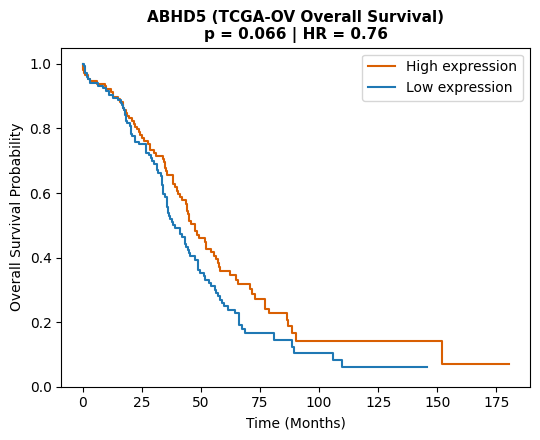

[ABHD5] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_ABHD5.png


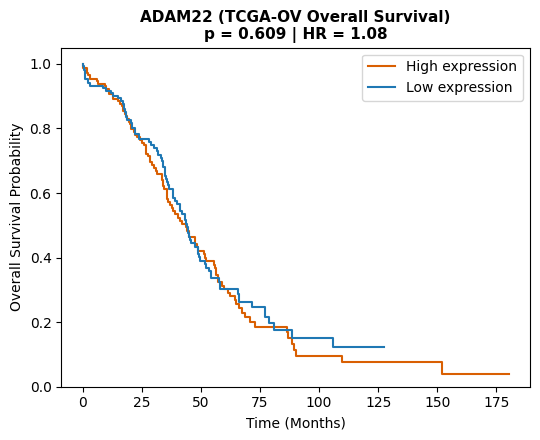

[ADAM22] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_ADAM22.png


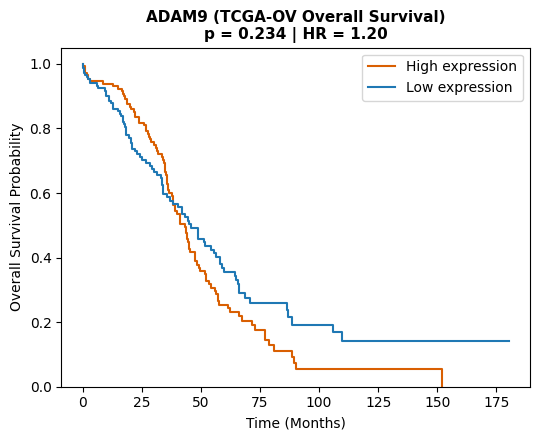

[ADAM9] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_ADAM9.png


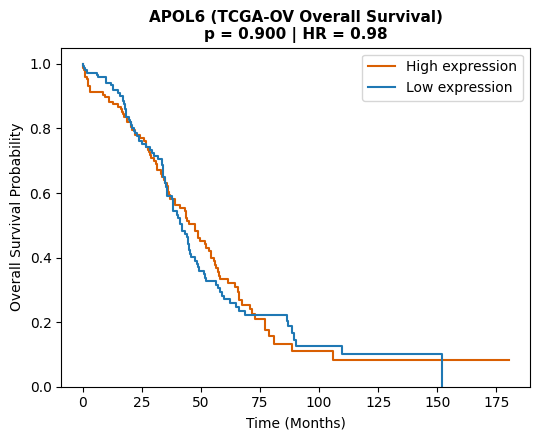

[APOL6] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_APOL6.png


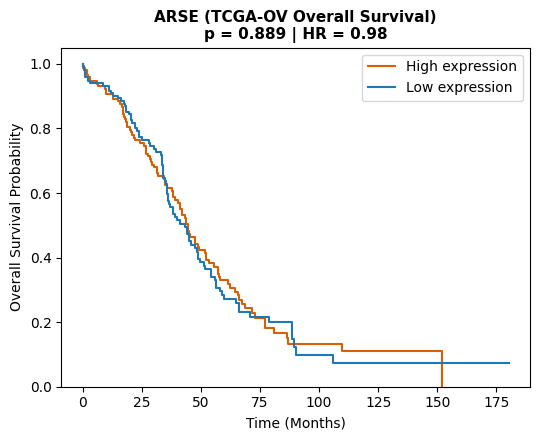

[ARSE] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_ARSE.png


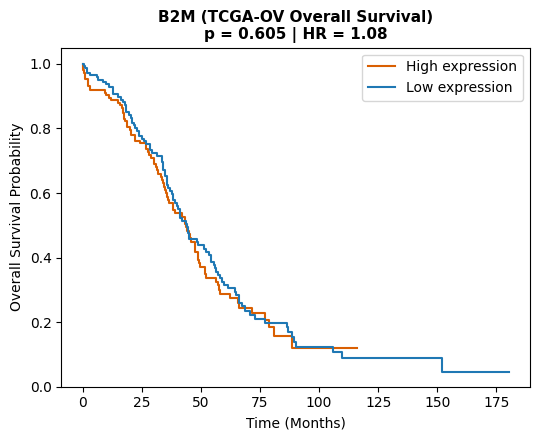

[B2M] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_B2M.png


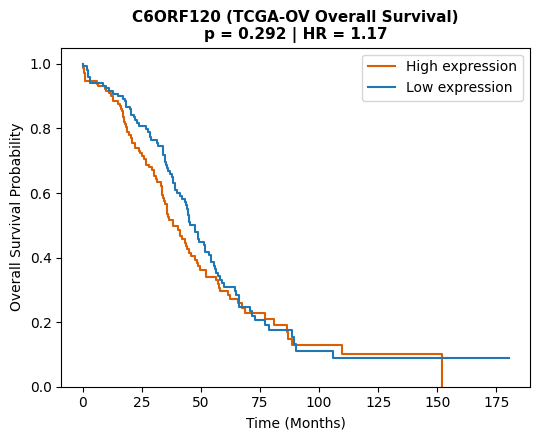

[C6ORF120] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_C6ORF120.png


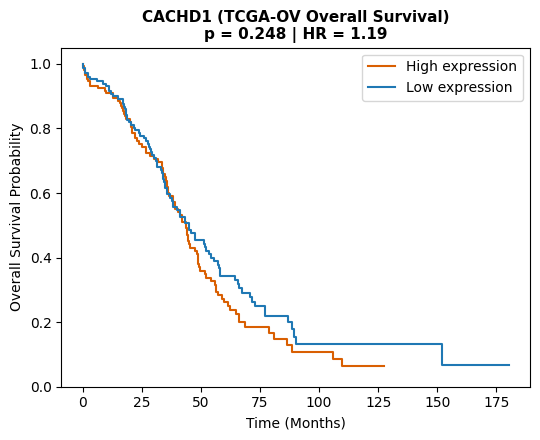

[CACHD1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_CACHD1.png


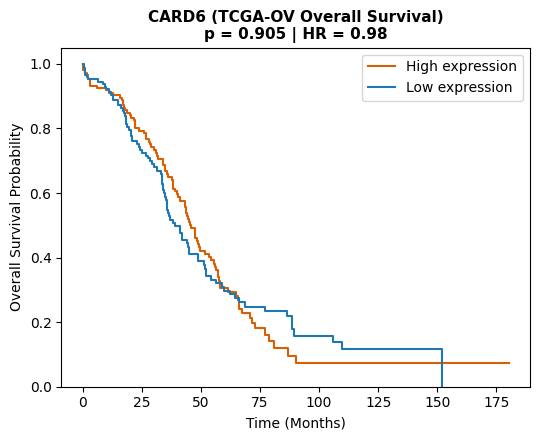

[CARD6] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_CARD6.png


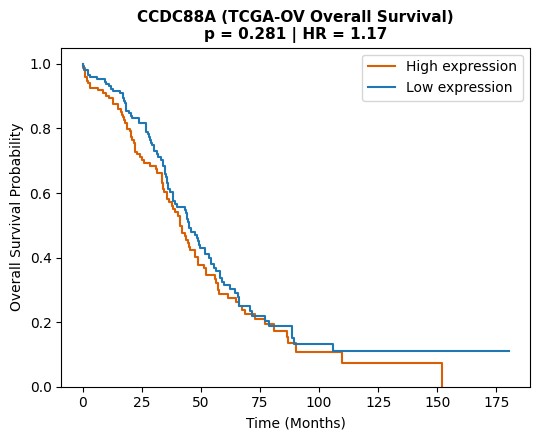

[CCDC88A] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_CCDC88A.png
[CECR1] Skipped: No TCGA expression data found.


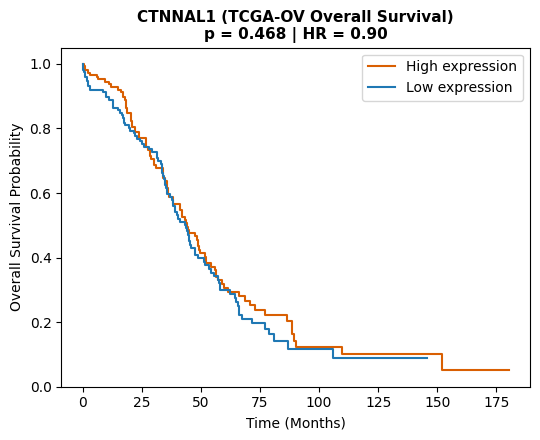

[CTNNAL1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_CTNNAL1.png


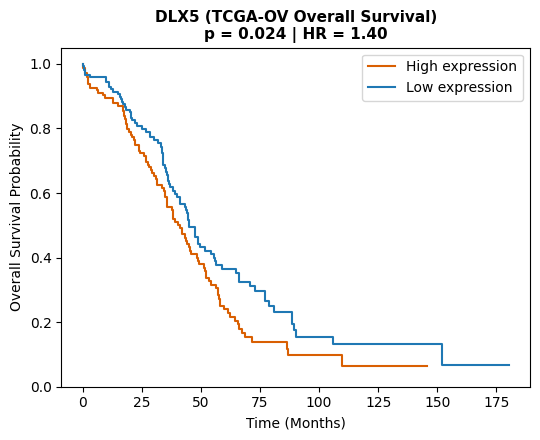

[DLX5] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_DLX5.png


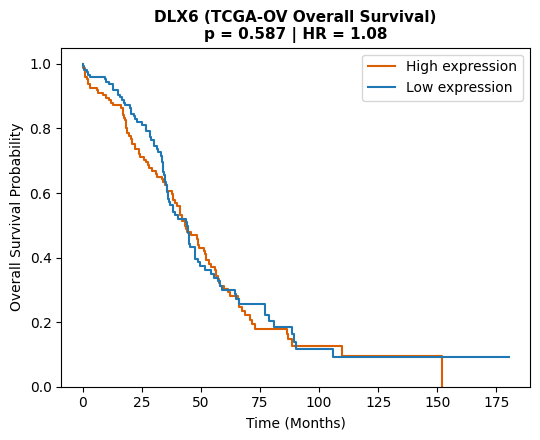

[DLX6] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_DLX6.png


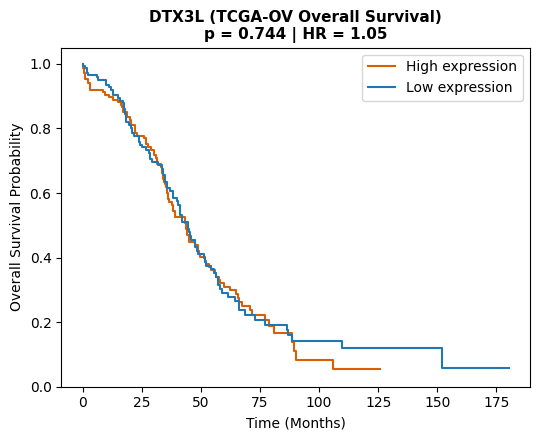

[DTX3L] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_DTX3L.png


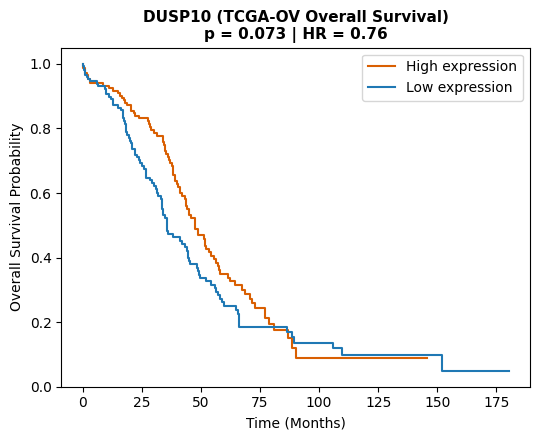

[DUSP10] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_DUSP10.png


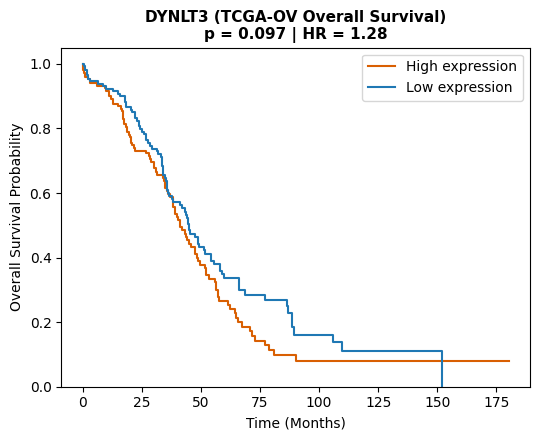

[DYNLT3] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_DYNLT3.png


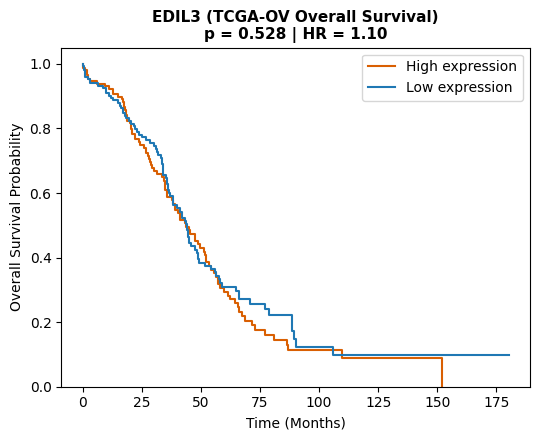

[EDIL3] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_EDIL3.png


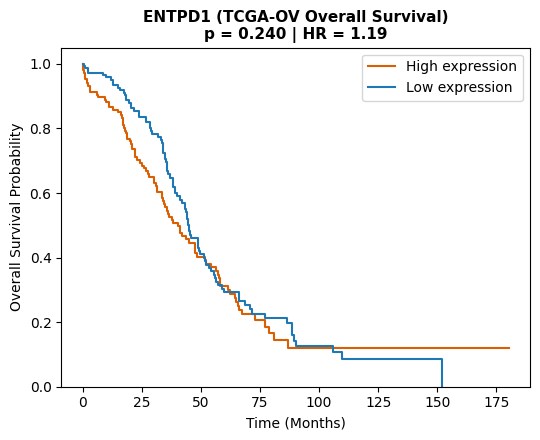

[ENTPD1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_ENTPD1.png


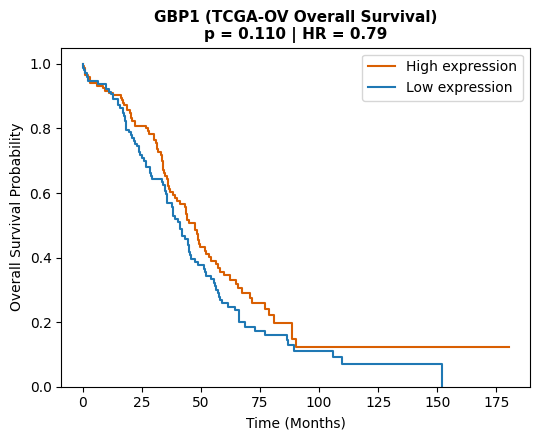

[GBP1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_GBP1.png


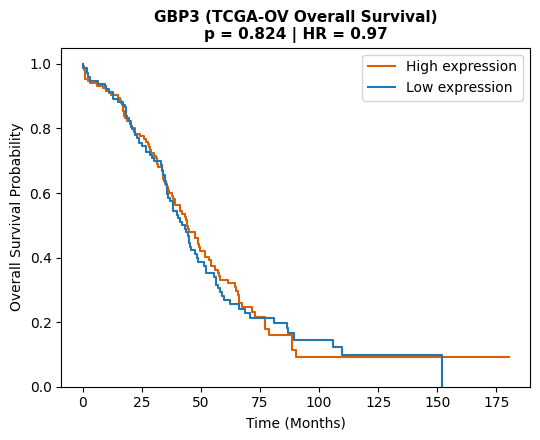

[GBP3] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_GBP3.png


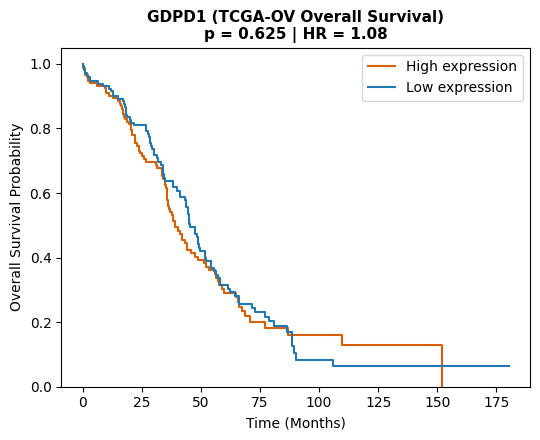

[GDPD1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_GDPD1.png


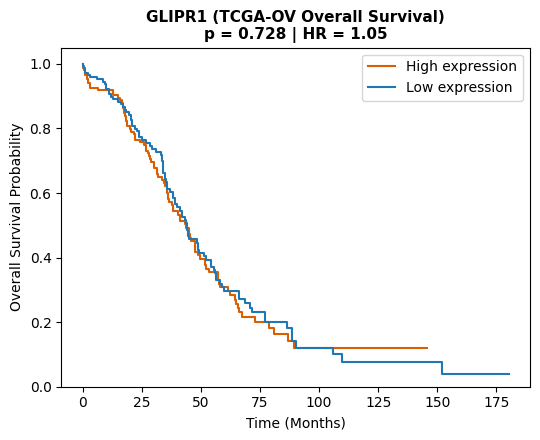

[GLIPR1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_GLIPR1.png


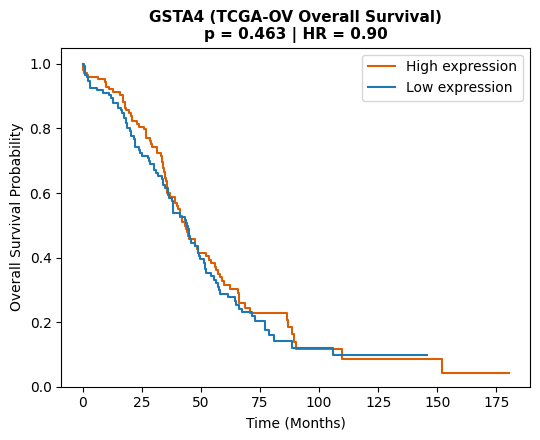

[GSTA4] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_GSTA4.png


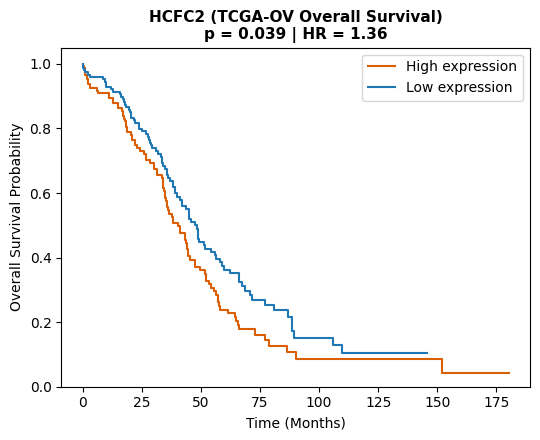

[HCFC2] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_HCFC2.png


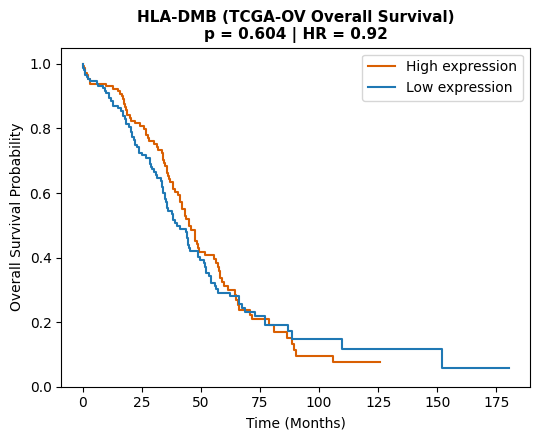

[HLA-DMB] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_HLA-DMB.png


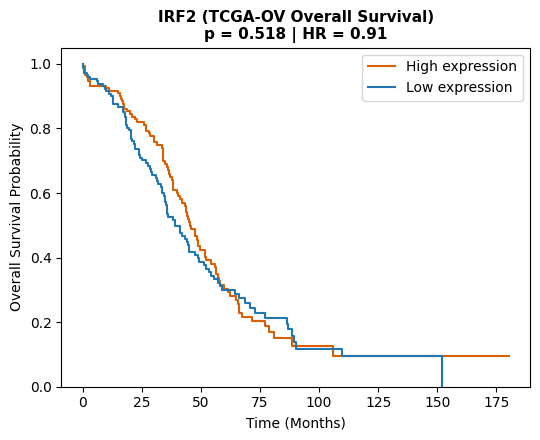

[IRF2] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_IRF2.png


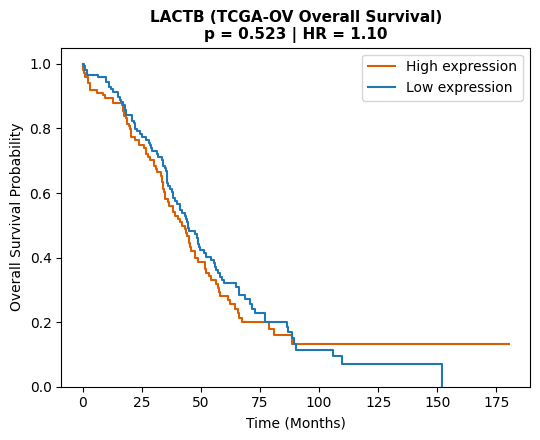

[LACTB] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_LACTB.png


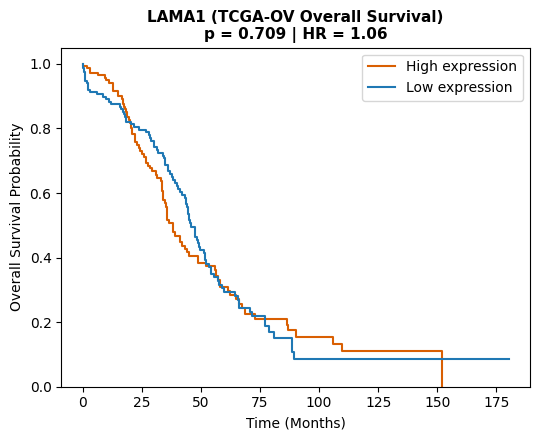

[LAMA1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_LAMA1.png


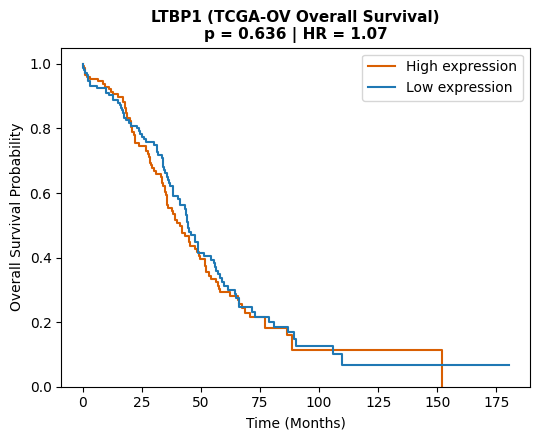

[LTBP1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_LTBP1.png


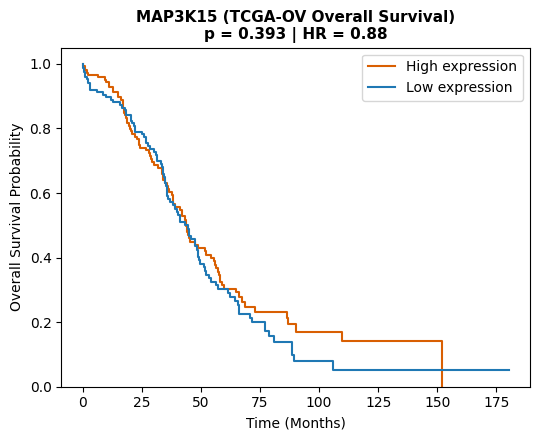

[MAP3K15] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_MAP3K15.png


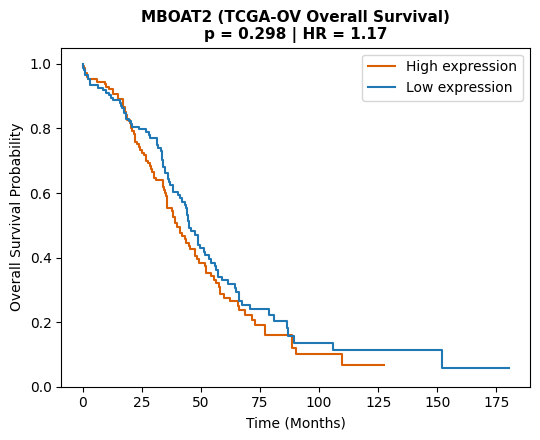

[MBOAT2] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_MBOAT2.png


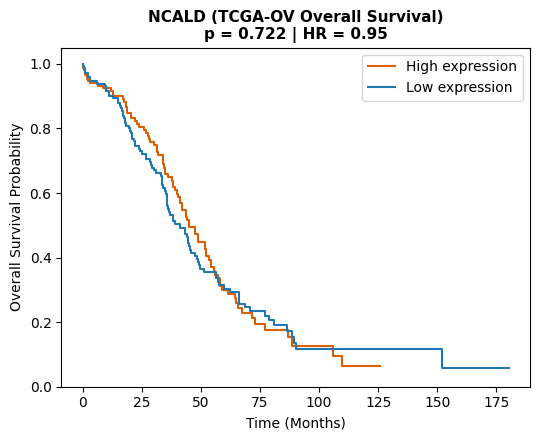

[NCALD] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_NCALD.png


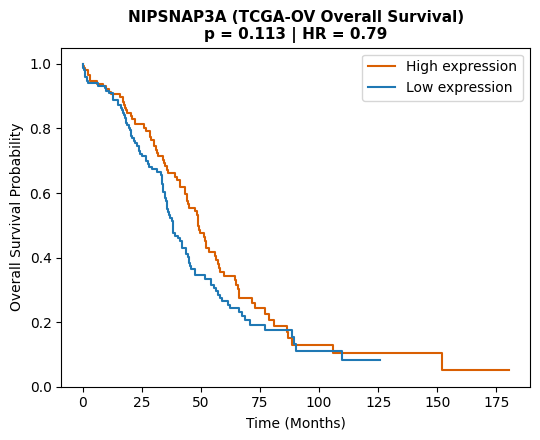

[NIPSNAP3A] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_NIPSNAP3A.png


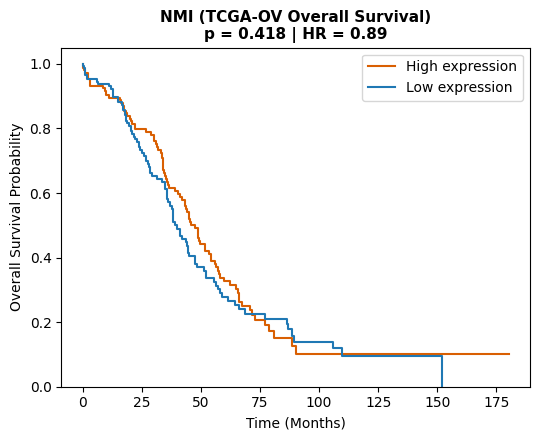

[NMI] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_NMI.png


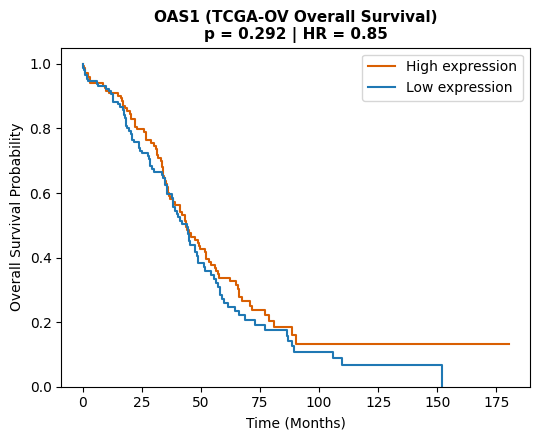

[OAS1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_OAS1.png


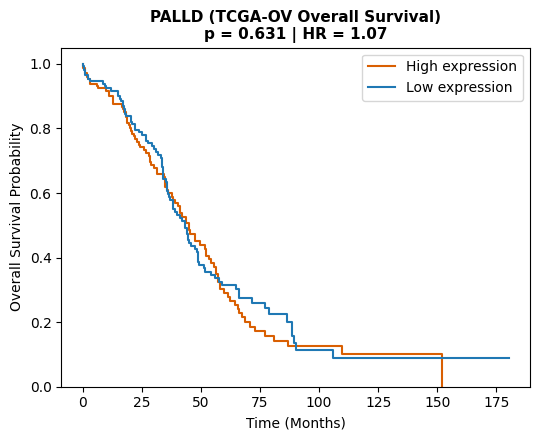

[PALLD] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_PALLD.png


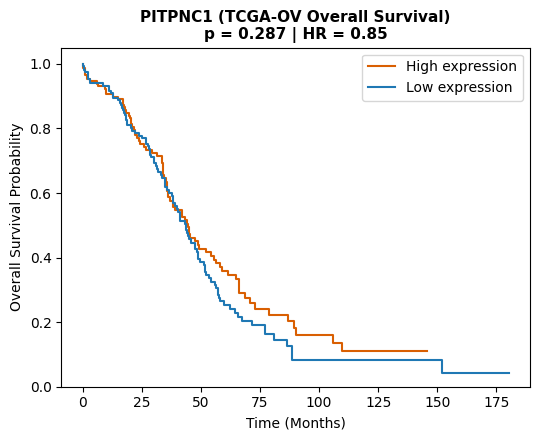

[PITPNC1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_PITPNC1.png


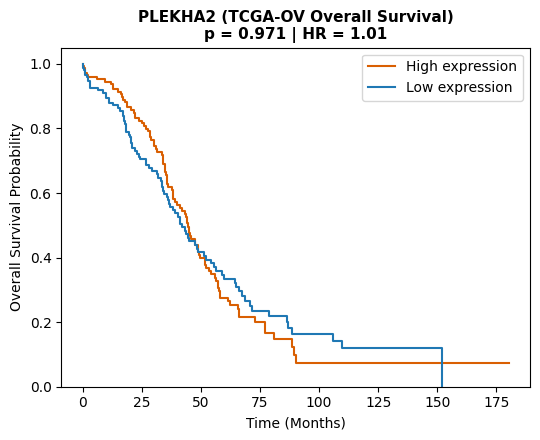

[PLEKHA2] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_PLEKHA2.png


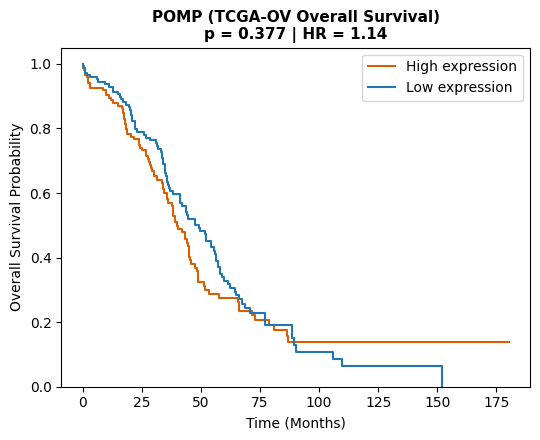

[POMP] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_POMP.png


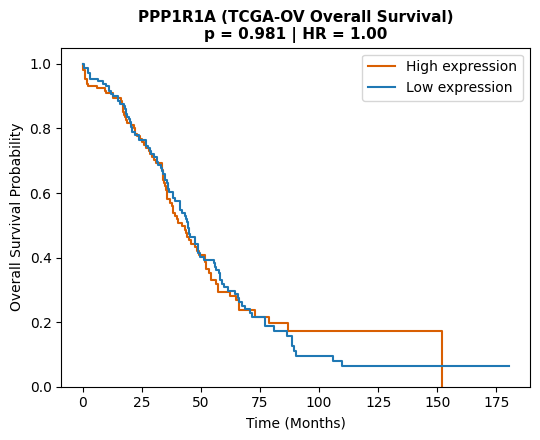

[PPP1R1A] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_PPP1R1A.png


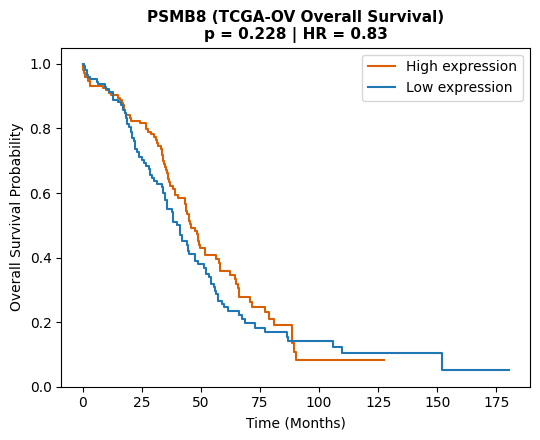

[PSMB8] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_PSMB8.png


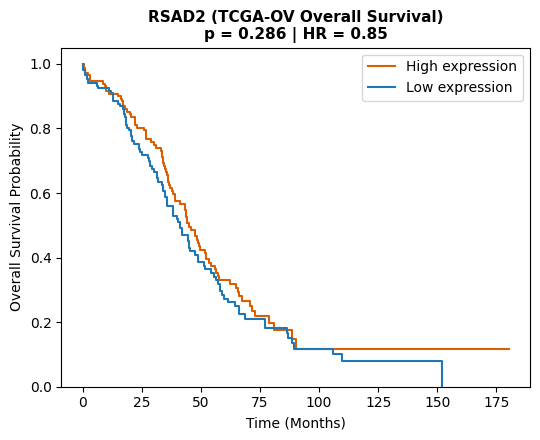

[RSAD2] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_RSAD2.png


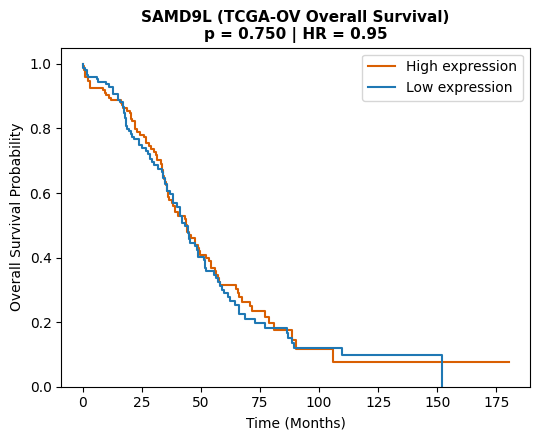

[SAMD9L] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_SAMD9L.png


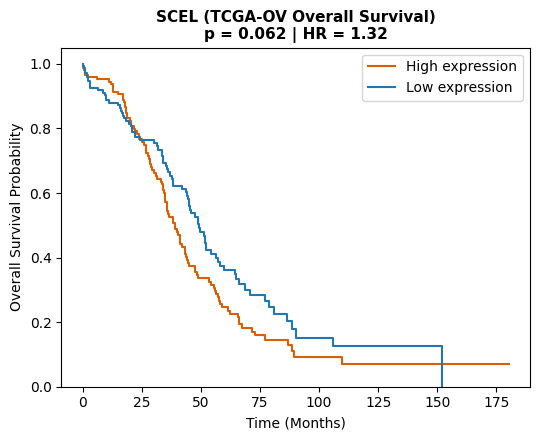

[SCEL] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_SCEL.png


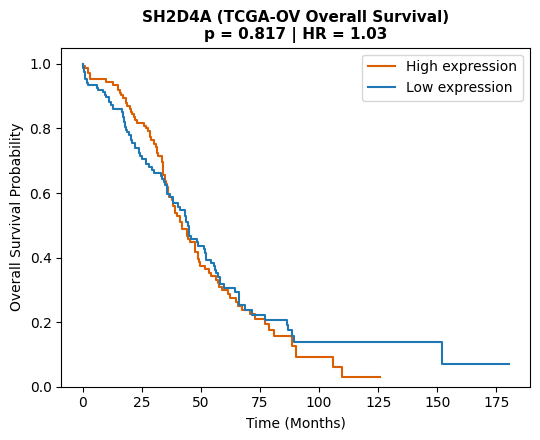

[SH2D4A] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_SH2D4A.png


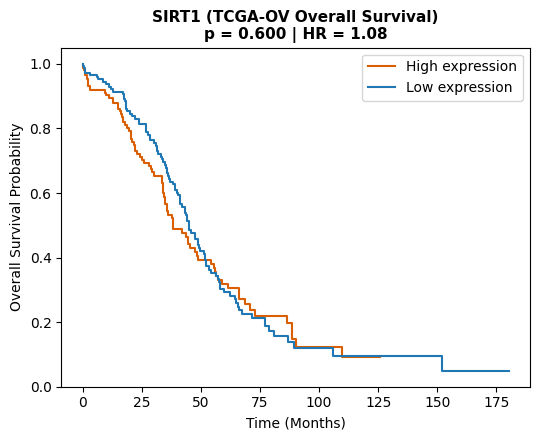

[SIRT1] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_SIRT1.png


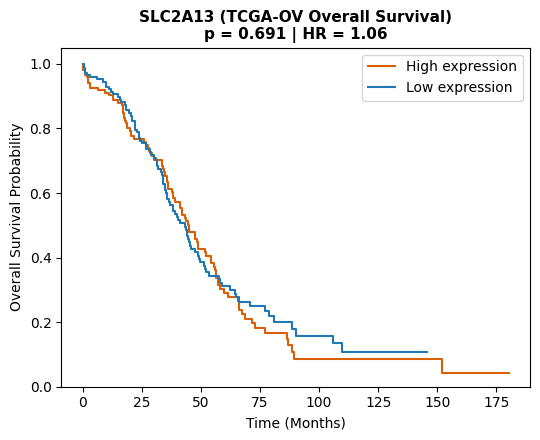

[SLC2A13] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_SLC2A13.png


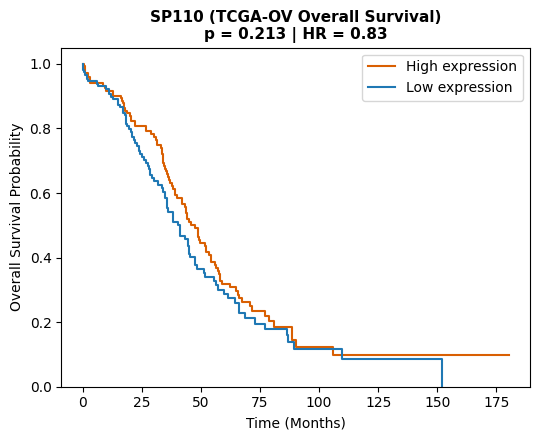

[SP110] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_SP110.png


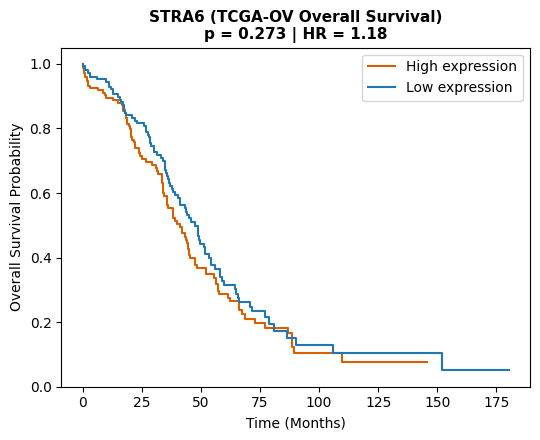

[STRA6] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_STRA6.png


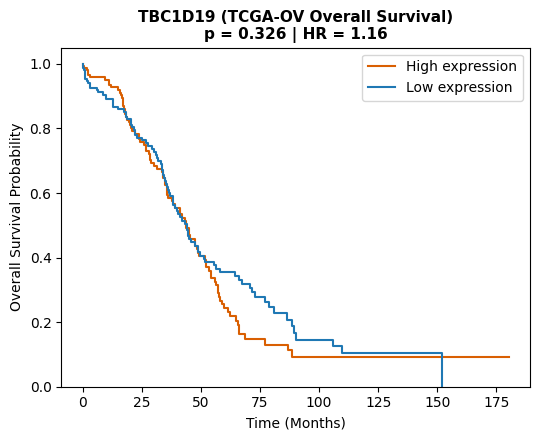

[TBC1D19] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_TBC1D19.png


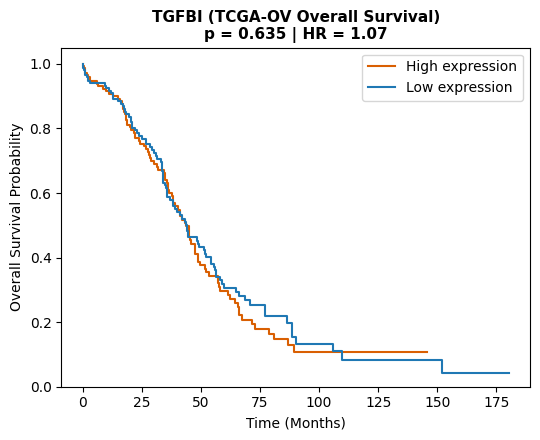

[TGFBI] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_TGFBI.png


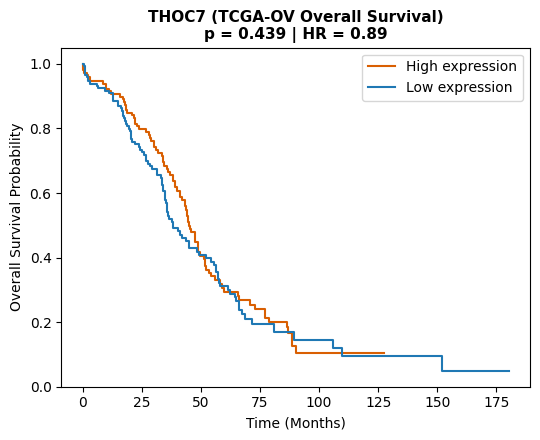

[THOC7] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_THOC7.png


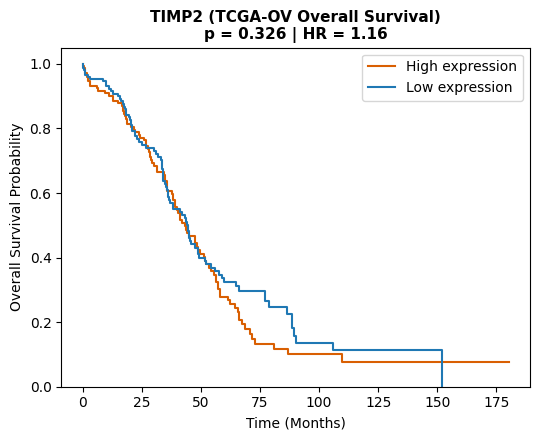

[TIMP2] KM plot saved -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\stage5_KM_TIMP2.png
[TSPAN12] Skipped: No TCGA expression data found.
[TUBA4A] Skipped: No TCGA expression data found.
[TUBE1] Skipped: No TCGA expression data found.
[WDR19] Skipped: No TCGA expression data found.
[XAF1] Skipped: No TCGA expression data found.
[ZAK] Skipped: No TCGA expression data found.
[ZBED2] Skipped: No TCGA expression data found.

All survival statistics saved to:
  -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\16_survival_results.csv
Prognostic genes (p < 0.05) saved to:
  -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\17_prognostic_genes.csv
Prognostic candidate count: 2 / 53


In [ ]:

# 5. Run Across Replicated Candidate Genes

print("\n--- Running TCGA Survival Analysis ---")
results = []
for g in replicated_genes:
    res = run_survival(g, make_plot=True)
    if res is not None:
        results.append(res)

survival_df = pd.DataFrame(results)

# Save 16_survival_results.csv
csv_survival = os.path.join(DIR_TABLES, "16_survival_results.csv")
survival_df.to_csv(csv_survival, index=False)
print(f"\nAll survival statistics saved to:\n  -> {csv_survival}")

# Filter and save 17_prognostic_genes.csv (p < 0.05)
if not survival_df.empty:
    prog_df = survival_df[survival_df["logrank_p"] < 0.05]
    csv_prog = os.path.join(DIR_TABLES, "17_prognostic_genes.csv")
    prog_df[["gene"]].to_csv(csv_prog, index=False)
    print(f"Prognostic genes (p < 0.05) saved to:\n  -> {csv_prog}")
    print(f"Prognostic candidate count: {len(prog_df)} / {len(survival_df)}")

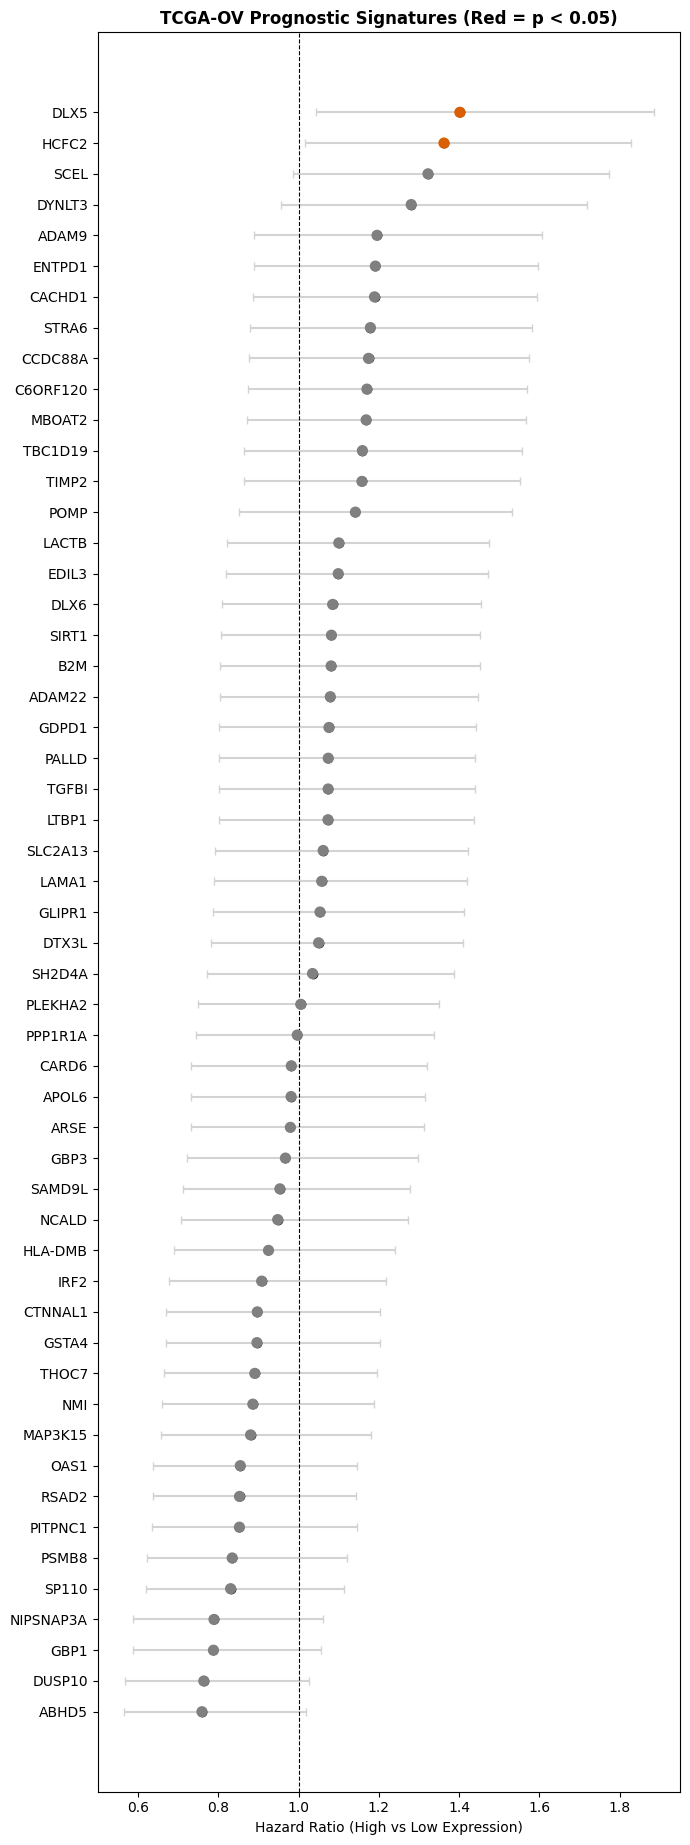

Forest plot saved to:
  -> C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\11_stage5_HR_forest_plot.png


In [ ]:

# 6. Forest Plot of Hazard Ratios

if not survival_df.empty and len(survival_df) > 1:
    sr = survival_df.dropna(subset=["HR_lower", "HR_upper"]).sort_values("HR").reset_index(drop=True)
    if len(sr) > 0:
        plt.figure(figsize=(7, max(4, len(sr) * 0.35)))
        colors = np.where(sr["logrank_p"] < 0.05, "#d95f02", "gray")
        y_pos = np.arange(len(sr))

        plt.errorbar(
            sr["HR"], y_pos,
            xerr=[sr["HR"] - sr["HR_lower"], sr["HR_upper"] - sr["HR"]],
            fmt="o", color="black", ecolor="lightgray", elinewidth=1.5, capsize=3
        )
        plt.scatter(sr["HR"], y_pos, c=colors, s=50, zorder=3)
        plt.yticks(y_pos, sr["gene"])
        plt.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
        plt.xlabel("Hazard Ratio (High vs Low Expression)")
        plt.title("TCGA-OV Prognostic Signatures (Red = p < 0.05)", fontweight="bold")
        plt.tight_layout()
        
        forest_out = os.path.join(DIR_FIGURES, "11_stage5_HR_forest_plot.png")
        plt.savefig(forest_out, dpi=1000)
        plt.show()
        plt.close()
        print(f"Forest plot saved to:\n  -> {forest_out}")